<a href="https://colab.research.google.com/github/IshaCodex/OIBSIP/blob/main/DataAnalytics-L2-HousePricePrediction/Task1_HousePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('/content/AmesHousing.csv')

# Exploratory Data Analysis (EDA)

We will perform an initial inspection, check for null values, calculate descriptive statistics, and plot the distribution of our target variable (SalePrice).

Dataset Shape: (2930, 82)

--- Top 10 Columns with Missing Values ---
Pool QC          2917
Misc Feature     2824
Alley            2732
Fence            2358
Mas Vnr Type     1775
Fireplace Qu     1422
Lot Frontage      490
Garage Qual       159
Garage Yr Blt     159
Garage Cond       159
dtype: int64

--- Descriptive Statistics for SalePrice ---


,SalePrice
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


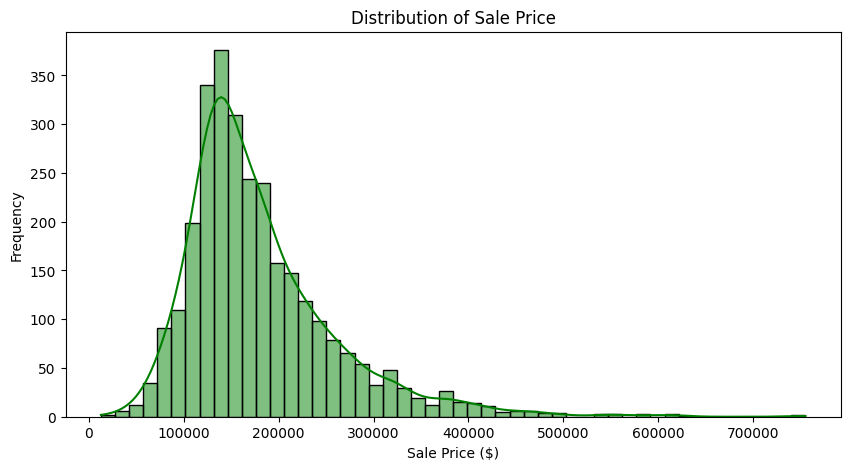

In [2]:
print("Dataset Shape:", df.shape)
print("\n--- Top 10 Columns with Missing Values ---")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\n--- Descriptive Statistics for SalePrice ---")
display(df['SalePrice'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df['SalePrice'], bins=50, kde=True, color='green')
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')
plt.show()

# Feature Selection Discussion

The dataset contains 82 columns, which is too many for a baseline linear regression model. To avoid the "curse of dimensionality" and multicollinearity, I will select a subset of features that are universally known to impact house prices:

Overall Qual: Rates the overall material and finish of the house (highly correlated with price).

Gr Liv Area: Above grade (ground) living area square feet.

Total Bsmt SF: Total square feet of the basement area.

Bedroom AbvGr: Number of bedrooms above basement level.

Full Bath: Full bathrooms above grade.

Neighborhood: Physical location (requires One-Hot Encoding).

In [3]:
# Select the chosen features and the target variable
selected_features = ['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF',
                     'Bedroom AbvGr', 'Full Bath', 'Neighborhood', 'SalePrice']

df_subset = df[selected_features].copy()

# Handle Missing Values and Categorical Encoding

We will fill any missing numerical values with the median, and then apply One-Hot Encoding to the categorical Neighborhood feature.

In [4]:
# Handle missing values in numerical columns
df_subset['Total Bsmt SF'] = df_subset['Total Bsmt SF'].fillna(df_subset['Total Bsmt SF'].median())

# Apply One-Hot Encoding to 'Neighborhood'
df_encoded = pd.get_dummies(df_subset, columns=['Neighborhood'], drop_first=True)

print("New shape after One-Hot Encoding:", df_encoded.shape)

New shape after One-Hot Encoding: (2930, 33)


# Correlation Heatmap

Before modeling, we will check how our numerical features correlate with SalePrice

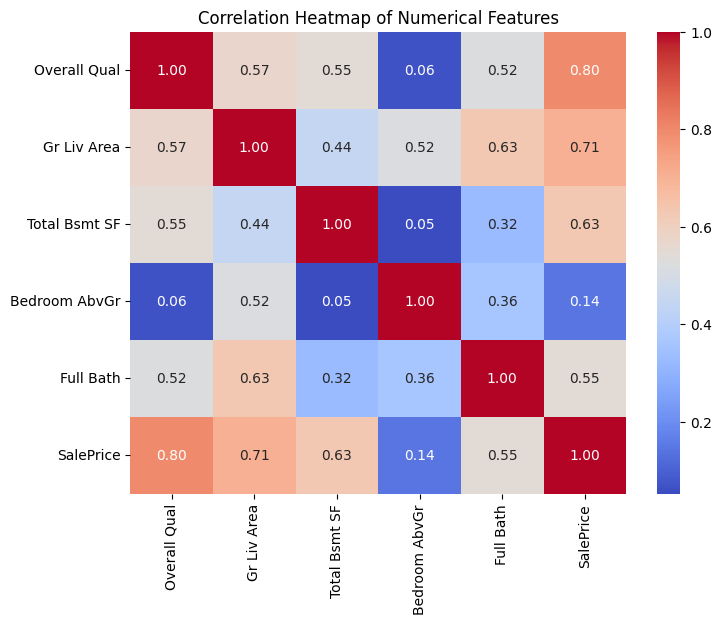

In [5]:
plt.figure(figsize=(8, 6))
# Calculate correlation for the original numerical features (before encoding)
corr_matrix = df_subset[['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF',
                         'Bedroom AbvGr', 'Full Bath', 'SalePrice']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Train / Test Split

We will separate our data into features (X) and the target (y), and then split them using an 80/20 ratio for training and testing.

In [6]:
# Separate features (X) and target (y)
X = df_encoded.drop('SalePrice', axis=1)
y = df_encoded['SalePrice']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (2344, 32)
Testing data size: (586, 32)


# Train the Linear Regression Model

We will instantiate the Linear Regression model and fit it to our training data.

In [7]:
# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = lr_model.predict(X_test)

# Model Evaluation

We evaluate the model using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the R² score to determine how well our features explain the variance in house prices.

In [8]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Linear Regression Evaluation Metrics:
Mean Squared Error (MSE): 1,317,883,934.65
Root Mean Squared Error (RMSE): $36,302.67
R-squared (R2) Score: 0.8356


# Scatter Plot: Actual vs. Predicted Prices

We will plot the actual prices against our model's predicted prices. The closer the points are to a perfect diagonal line, the more accurate the model is.

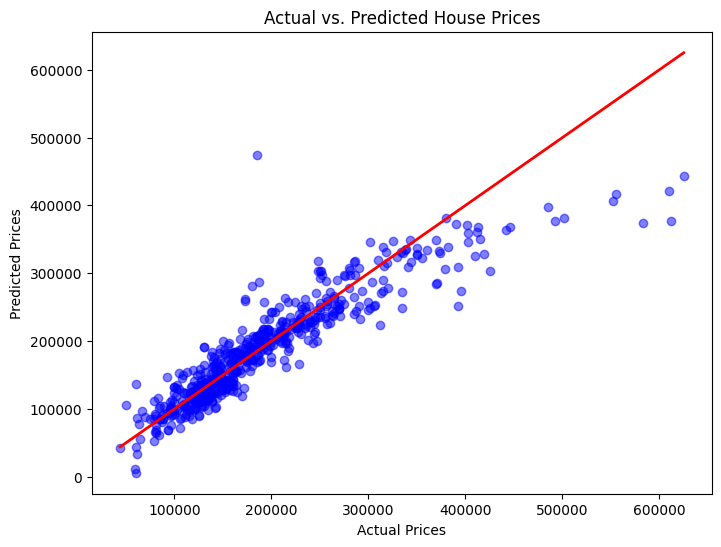

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')

# Plot the perfect prediction diagonal line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)

plt.title('Actual vs. Predicted House Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.show()

# Residual Plot

We will plot the residuals (the difference between actual and predicted values). A good model should have residuals randomly scattered around the zero line with no clear pattern.

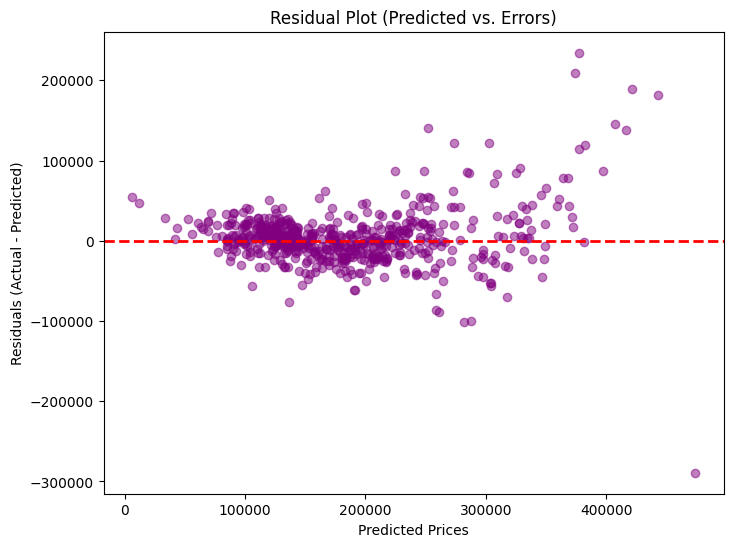

In [10]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Residual Plot (Predicted vs. Errors)')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

# Coefficient Analysis

We will examine the coefficients assigned to our features by the model to see which factors have the highest positive or negative impact on the price.

In [11]:
# Create a DataFrame of the coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})

# Sort by the most impactful features (both positive and negative)
coefficients['Absolute'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Absolute', ascending=False).drop('Absolute', axis=1)

print("Top 10 Most Impactful Features:")
display(coefficients.head(10))

Top 10 Most Impactful Features:


,Feature,Coefficient
14,Neighborhood_GrnHill,97767.086636
29,Neighborhood_StoneBr,74130.820043
23,Neighborhood_NridgHt,66589.045591
22,Neighborhood_NoRidge,65017.849125
30,Neighborhood_Timber,32373.271098
31,Neighborhood_Veenker,26752.123705
6,Neighborhood_BrDale,-25378.033266
28,Neighborhood_Somerst,24393.624098
8,Neighborhood_ClearCr,22694.056573
25,Neighborhood_SWISU,-20998.177720


# Bonus: Compare with Ridge and Lasso Regression

Linear regression can sometimes overfit when One-Hot Encoding creates many features. We will compare our standard model against L2 (Ridge) and L1 (Lasso) regularized models.

In [12]:
# Train Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

# Train Lasso Regression
lasso_model = Lasso(alpha=100.0, max_iter=10000)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

# Print comparison
print("--- R-squared (R2) Comparison ---")
print(f"Standard Linear Regression: {r2_score(y_test, y_pred):.4f}")
print(f"Ridge Regression:           {r2_score(y_test, ridge_pred):.4f}")
print(f"Lasso Regression:           {r2_score(y_test, lasso_pred):.4f}")

--- R-squared (R2) Comparison ---
Standard Linear Regression: 0.8356
Ridge Regression:           0.8356
Lasso Regression:           0.8336
